In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import urllib.request


In [8]:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv'

with open('groceries.csv', 'w') as f:
    response = urllib.request.urlopen(url)
    f.write(response.read().decode('utf-8'))

data = []
with open('groceries.csv', 'r') as f:
    for line in f:
        data.append(line.strip().split(','))

In [9]:
te = TransactionEncoder()
te_ary = te.fit(data).transform(data)
df = pd.DataFrame(te_ary, columns=te.columns_)
df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [10]:
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.5)

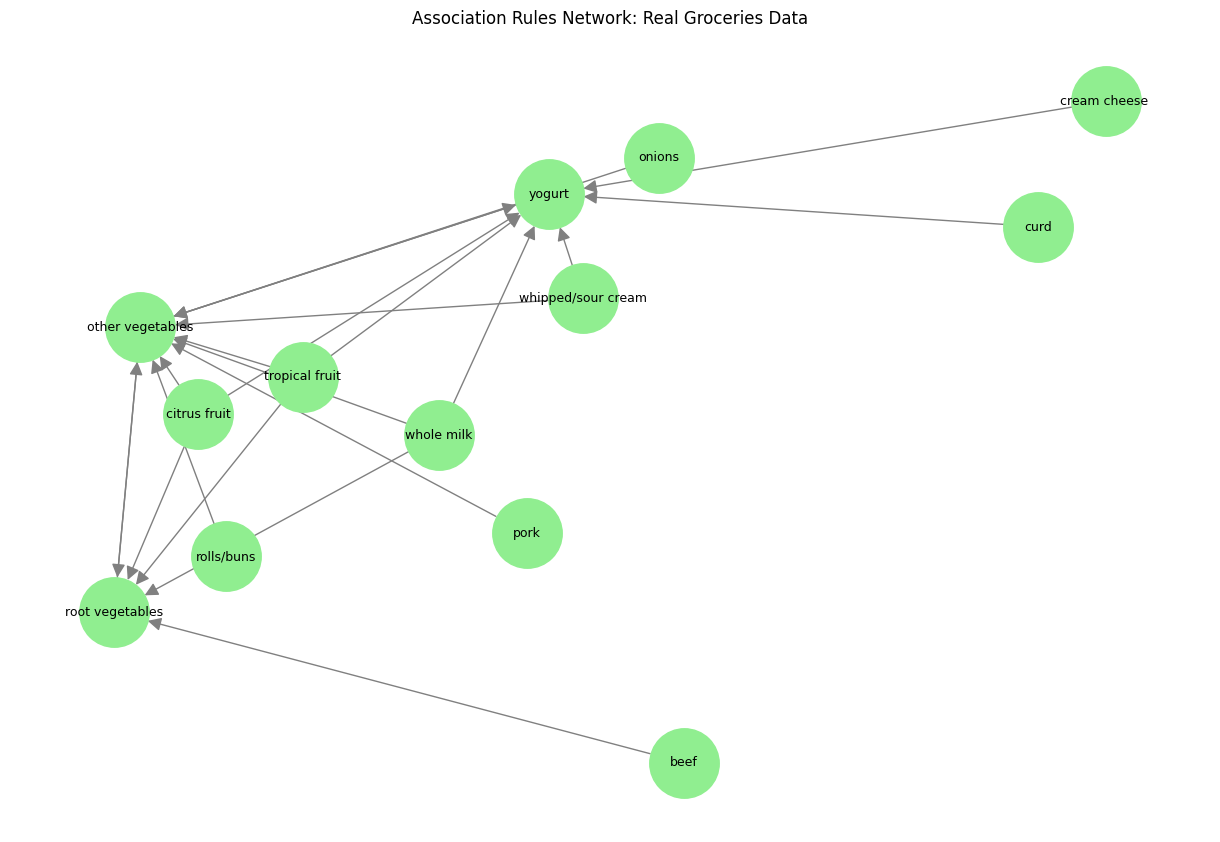

In [11]:
plt.figure(figsize=(12, 8))
strong_rules = rules[rules['confidence'] > 0.3].nlargest(20, 'lift')

G = nx.DiGraph()
for _, row in strong_rules.iterrows():
    for ant in row['antecedents']:
        for cons in row['consequents']:
            G.add_edge(ant, cons, weight=row['lift'])

pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2500, 
        edge_color='gray', arrowsize=20, font_size=9)

plt.title('Association Rules Network: Real Groceries Data')
plt.show()

In [13]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
0,(beef),(other vegetables),0.019725,0.375969,1.943066
1,(other vegetables),(beef),0.019725,0.101944,1.943066
2,(beef),(root vegetables),0.017387,0.331395,3.040367
3,(root vegetables),(beef),0.017387,0.159515,3.040367
4,(beef),(whole milk),0.021251,0.405039,1.585180
5,(whole milk),(beef),0.021251,0.083168,1.585180
6,(beef),(yogurt),0.011693,0.222868,1.597601
7,(yogurt),(beef),0.011693,0.083819,1.597601
8,(berries),(other vegetables),0.010269,0.308869,1.596280
9,(other vegetables),(berries),0.010269,0.053074,1.596280
